In [103]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

In [104]:
df = pd.read_csv('../data/processed/preprocesses_data.csv')

In [105]:
df.columns

Index(['age', 'study_hours', 'attendance_percentage', 'math_score',
       'science_score', 'english_score', 'overall_score', 'travel_time_min',
       'gender_male', 'gender_other', 'school_type_encoded',
       'parent_education_encoded', 'internet_access_encoded',
       'extra_activities_encoding', 'study_method_group_study',
       'study_method_mixed', 'study_method_notes',
       'study_method_online_videos', 'study_method_textbook',
       'final_grade_encoded'],
      dtype='object')

Select Features and Target

In [106]:
X = df.drop(columns=['final_grade_encoded'])
# X = df[['study_hours','math_score','science_score','english_score','overall_score','travel_time_min','parent_education_encoded']]

In [121]:
X.columns

Index(['age', 'study_hours', 'attendance_percentage', 'math_score',
       'science_score', 'english_score', 'overall_score', 'travel_time_min',
       'gender_male', 'gender_other', 'school_type_encoded',
       'parent_education_encoded', 'internet_access_encoded',
       'extra_activities_encoding', 'study_method_group_study',
       'study_method_mixed', 'study_method_notes',
       'study_method_online_videos', 'study_method_textbook'],
      dtype='object')

In [107]:
X.head()

,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score,travel_time_min,gender_male,gender_other,school_type_encoded,parent_education_encoded,internet_access_encoded,extra_activities_encoding,study_method_group_study,study_method_mixed,study_method_notes,study_method_online_videos,study_method_textbook
0,14,3.1,84.3,42.7,55.4,57.0,53.1,7.5,1,0,0,4.0,1,1,0,0,1,0,0
1,18,3.7,87.8,57.6,68.8,64.8,61.3,75.0,0,0,0,3.0,1,0,0,0,0,0,1
2,17,7.9,65.5,84.8,95.0,79.2,89.6,7.5,0,0,1,4.0,0,0,0,0,1,0,0
3,16,1.1,58.1,44.4,27.5,54.7,41.6,22.5,0,1,0,1.0,0,0,0,0,1,0,0
4,16,1.3,61.0,8.9,32.7,30.0,25.4,45.0,0,0,0,1.0,1,1,1,0,0,0,0


In [108]:
y = df['final_grade_encoded']

In [109]:
y.head()

0    4
1    3
2    1
3    4
4    5
Name: final_grade_encoded, dtype: int64

Train/Test Split

In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Model Selection

Logistic Regression

In [111]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred)
print("Accuracy of LR:",accuracy_lr)

print(classification_report(y_test,y_pred))

Accuracy of LR: 0.9406666666666667
              precision    recall  f1-score   support

           0       0.99      0.86      0.92       155
           1       0.89      0.92      0.90       314
           2       0.94      0.94      0.94       752
           3       0.94      0.94      0.94       721
           4       0.94      0.96      0.95       670
           5       0.98      0.95      0.96       388

    accuracy                           0.94      3000
   macro avg       0.95      0.93      0.94      3000
weighted avg       0.94      0.94      0.94      3000



Decision Tree

In [112]:
dc_model = DecisionTreeClassifier()

dc_model.fit(X_train,y_train)

y_pred = dc_model.predict(X_test)
accuracy_dc = accuracy_score(y_test,y_pred)

print("Accuracy of DC:",accuracy_dc)


Accuracy of DC: 0.994


In [113]:
importance = dc_model.feature_importances_

for f, i in zip(X_train,importance):
    print(f,i)

age 0.00036926704695589886
study_hours 0.00031402237063966204
attendance_percentage 0.00046746511992949686
math_score 0.00023925513953498056
science_score 0.0012382270890455343
english_score 0.00028303492613986634
overall_score 0.9960734332900772
travel_time_min 0.0005567226669020151
gender_male 0.0
gender_other 0.0
school_type_encoded 0.0
parent_education_encoded 0.00013956549806207202
internet_access_encoded 0.0
extra_activities_encoding 0.0
study_method_group_study 0.000139565498062072
study_method_mixed 0.00017944135465123548
study_method_notes 0.0
study_method_online_videos 0.0
study_method_textbook 0.0


Prevent Overfitting for Decision Tree Model

In [114]:
dc_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=5,
)

dc_model.fit(X_train,y_train)
y_pred = dc_model.predict(X_test)
accuracy_dc = accuracy_score(y_test,y_pred)

print("New Accuracy of DC:",accuracy_dc)

New Accuracy of DC: 0.9963333333333333


Save Decision Tree Model

In [115]:
joblib.dump(dc_model,'../models/decision_tree_model.pkl')

['../models/decision_tree_model.pkl']

Random Forest

In [116]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

mse = mean_squared_error(y_test,y_pred_rf)
mae = mean_absolute_error(y_test,y_pred_rf)
r2 = r2_score(y_test,y_pred_rf)

print("Accuracy of RF:", accuracy_rf)
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)
print(classification_report(y_test,y_pred_rf))

Accuracy of RF: 0.995
MAE: 0.005
MSE: 0.005
R2 Score: 0.9973079360430214
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       155
           1       0.98      1.00      0.99       314
           2       0.99      0.99      0.99       752
           3       1.00      1.00      1.00       721
           4       1.00      1.00      1.00       670
           5       0.99      1.00      1.00       388

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       1.00      0.99      0.99      3000



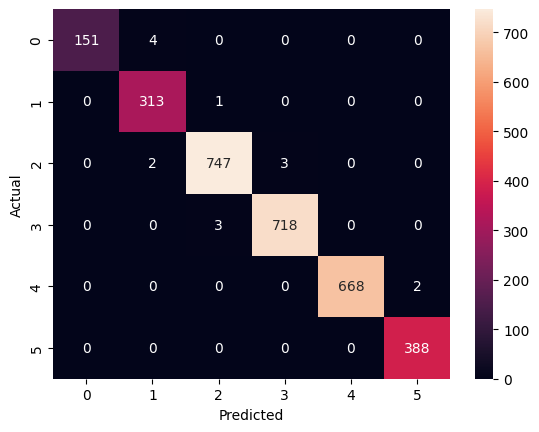

In [117]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

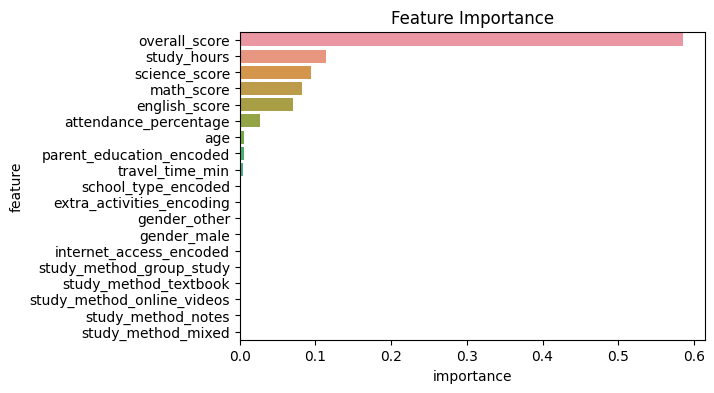

In [118]:
importances = rf_model.feature_importances_

feat_impt = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x='importance',y='feature', data=feat_impt)

# plt.barh(feat_impt['feature'], feat_impt['importance'])
plt.title("Feature Importance")
plt.show()

Save Random Forest Model

In [119]:
with open("../models/random_forest_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Model saved successfully!")

Model saved successfully!


In [120]:
knn_model = KNeighborsClassifier()

knn_model.fit(X_train,y_train)

y_pred = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test,y_pred)

print("Accuracy of KNN:", accuracy_knn)
print(classification_report(y_test,y_pred))

Accuracy of KNN: 0.8543333333333333
              precision    recall  f1-score   support

           0       0.93      0.81      0.87       155
           1       0.79      0.83      0.81       314
           2       0.88      0.86      0.87       752
           3       0.85      0.87      0.86       721
           4       0.84      0.86      0.85       670
           5       0.88      0.83      0.85       388

    accuracy                           0.85      3000
   macro avg       0.86      0.84      0.85      3000
weighted avg       0.86      0.85      0.85      3000

